# Model Tuning

Коротко: тюним лучшие модели через Optuna, сохраняем study-кэш и финальную модель.


## Setup / Настройка


In [1]:
# База / core
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

# Sklearn / ML
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Корень проекта / project root
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())

# Стиль / style
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 70)
plt.rcParams["figure.figsize"] = (8, 4)


## Data / Данные


In [2]:
# Данные после FE / data after feature engineering
df_model = pd.read_parquet(ROOT / "data" / "titanic_fe.parquet")

X = df_model.drop(columns="survived")
y = df_model["survived"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)


## Preprocessing / Предобработка


In [3]:
# Features & preprocessing
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])

## Tuning Cache / Кэш


In [4]:
# Кэш тюнинга / tuning cache
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)


def get_or_run_study(name, objective, n_trials=50):
    """Загружаем study из кэша или запускаем Optuna / load cache or run Optuna."""
    path = MODELS_DIR / f"study_{name}.pkl"

    if path.exists():
        study = joblib.load(path)
        print(f"[{name}] загружен из кэша ({len(study.trials)} trials) — тюнинг пропущен.")
        return study

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)
    joblib.dump(study, path)
    print(f"[{name}] тюнинг завершён, study сохранён → {path.name}")
    return study


## RandomForest / Случайный лес


In [5]:
def objective_rf(trial):
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 1500),
            max_depth=trial.suggest_int("max_depth", 3, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
            random_state=42, n_jobs=-1
        ))
    ])

    return cross_val_score(
        model, X_train, y_train,
        cv=5, scoring="accuracy", n_jobs=-1
    ).mean()


study_rf = get_or_run_study("rf", objective_rf, n_trials=50)

print("Best score:", study_rf.best_value)
print("Best params:", study_rf.best_params)

[rf] загружен из кэша (50 trials) — тюнинг пропущен.
Best score: 0.813734335839599
Best params: {'n_estimators': 1261, 'max_depth': 10, 'min_samples_split': 11, 'min_samples_leaf': 8, 'max_features': 'log2'}


/tmp/ipykernel_48097/3885261250.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_rf)


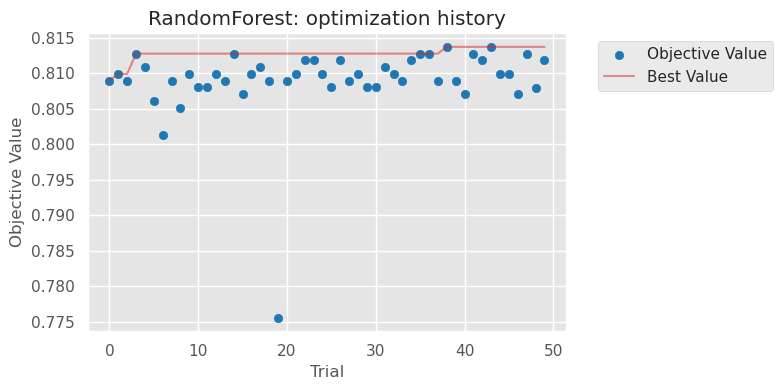

/tmp/ipykernel_48097/3885261250.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_rf)


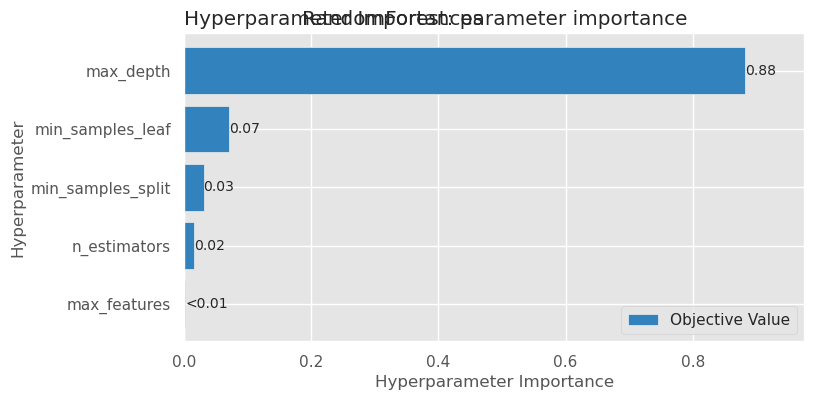

In [6]:
plot_optimization_history(study_rf)
plt.title("RandomForest: optimization history")
plt.show()

plot_param_importances(study_rf)
plt.title("RandomForest: parameter importance")
plt.show()

## HistGradientBoosting


In [7]:
def objective_hgb(trial):
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingClassifier(
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
            max_depth=trial.suggest_int("max_depth", 2, 15),
            max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 10, 100),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 50),
            l2_regularization=trial.suggest_float("l2_regularization", 0.0, 10.0),
            random_state=42
        ))
    ])

    return cross_val_score(
        model, X_train, y_train,
        cv=5, scoring="accuracy", n_jobs=-1
    ).mean()


study_hgb = get_or_run_study("hgb", objective_hgb, n_trials=50)

print("Best score:", study_hgb.best_value)
print("Best params:", study_hgb.best_params)

[hgb] загружен из кэша (50 trials) — тюнинг пропущен.
Best score: 0.817552973342447
Best params: {'learning_rate': 0.06972437006239854, 'max_depth': 3, 'max_leaf_nodes': 49, 'min_samples_leaf': 13, 'l2_regularization': 4.799708823701076}


/tmp/ipykernel_48097/915168542.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_hgb)


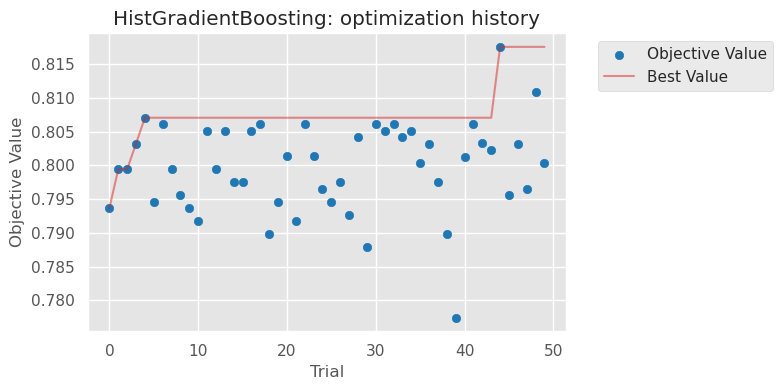

/tmp/ipykernel_48097/915168542.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_hgb)


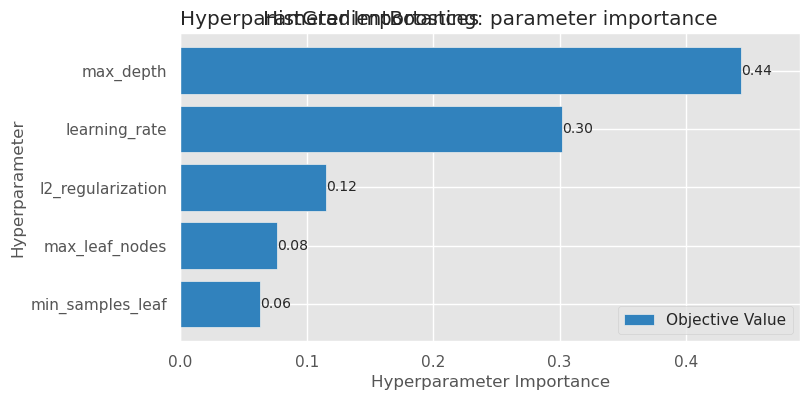

In [8]:
plot_optimization_history(study_hgb)
plt.title("HistGradientBoosting: optimization history")
plt.show()

plot_param_importances(study_hgb)
plt.title("HistGradientBoosting: parameter importance")
plt.show()

## CatBoost


In [9]:
def objective_cat(trial):
    return cross_val_score(
        Pipeline([
            ("preprocessor", preprocessor),
            ("model", CatBoostClassifier(
                iterations=trial.suggest_int("iterations", 100, 1000),
                depth=trial.suggest_int("depth", 3, 10),
                learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
                l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1, 10),
                bagging_temperature=trial.suggest_float("bagging_temperature", 0, 10),
                random_state=42, verbose=0
            ))
        ]),
        X_train, y_train,
        cv=5, scoring="accuracy", n_jobs=-1
    ).mean()


study_cat = get_or_run_study("cat", objective_cat, n_trials=50)

print("Best score:", study_cat.best_value)
print("Best params:", study_cat.best_params)

[cat] загружен из кэша (50 trials) — тюнинг пропущен.
Best score: 0.8070357712462976
Best params: {'iterations': 907, 'depth': 5, 'learning_rate': 0.013821972170467878, 'l2_leaf_reg': 7.065234741891823, 'bagging_temperature': 5.080554710431221}


/tmp/ipykernel_48097/2609850441.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_cat)


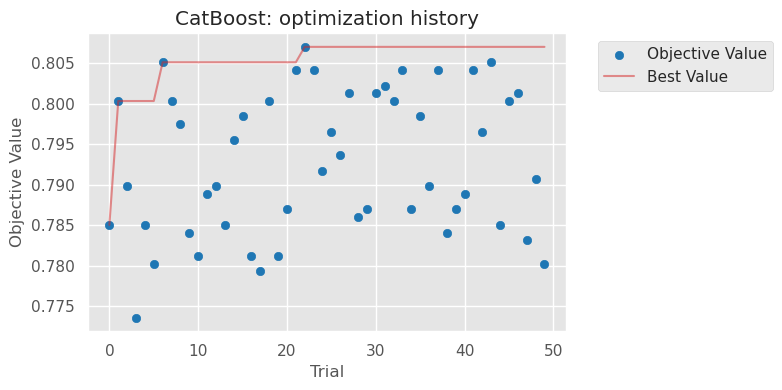

/tmp/ipykernel_48097/2609850441.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_cat)


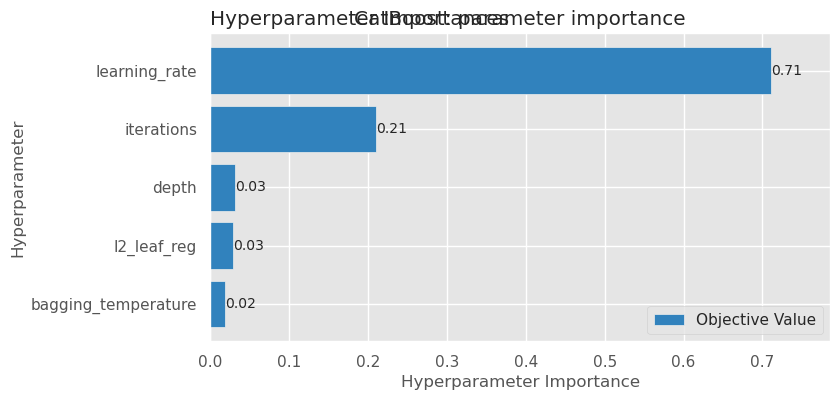

In [10]:
plot_optimization_history(study_cat)
plt.title("CatBoost: optimization history")
plt.show()

plot_param_importances(study_cat)
plt.title("CatBoost: parameter importance")
plt.show()

## Best Model / Лучшая модель


In [11]:
results = pd.DataFrame([
    {"model": "RandomForest", "cv_score": study_rf.best_value},
    {"model": "HistGradientBoosting", "cv_score": study_hgb.best_value},
    {"model": "CatBoost", "cv_score": study_cat.best_value}
])

results = results.sort_values("cv_score", ascending=False)

display(results)

,model,cv_score
1,HistGradientBoosting,0.817553
0,RandomForest,0.813734
2,CatBoost,0.807036


In [12]:
# Авто-лидер по CV / CV leader (для справки):
print("CV leader:", results.iloc[0]["model"])

# Тестовое задание требует RandomForest, его CV в пределах шума от лидера —
# финальной моделью фиксируем RandomForest / task mandates RandomForest.
best_model_name = "RandomForest"

print("Best model:", best_model_name)

CV leader: HistGradientBoosting
Best model: RandomForest


In [13]:
if best_model_name == "RandomForest":
    best_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            **study_rf.best_params,
            random_state=42, n_jobs=-1
        ))
    ])

elif best_model_name == "HistGradientBoosting":
    best_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingClassifier(
            **study_hgb.best_params,
            random_state=42
        ))
    ])

else:
    best_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", CatBoostClassifier(
            **study_cat.best_params,
            random_state=42, verbose=0
        ))
    ])

In [14]:
MODEL_PATH = MODELS_DIR / "best_model.pkl"

if MODEL_PATH.exists():
    best_model = joblib.load(MODEL_PATH)
    print("Loaded saved model.")
else:
    best_model.fit(X_train, y_train)
    joblib.dump(best_model, MODEL_PATH)
    print("Saved model.")

best_model

Loaded saved model.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Test Metrics / Метрики


In [15]:
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.8435


In [16]:
summary = pd.DataFrame([
    {"model": "RandomForest", "cv_score": study_rf.best_value},
    {"model": "HistGradientBoosting", "cv_score": study_hgb.best_value},
    {"model": "CatBoost", "cv_score": study_cat.best_value}
])

summary["test_accuracy"] = np.where(
    summary["model"] == best_model_name,
    test_accuracy,
    np.nan
)

display(summary.sort_values("cv_score", ascending=False).round(4))

,model,cv_score,test_accuracy
1,HistGradientBoosting,0.8176,NaN
0,RandomForest,0.8137,0.8435
2,CatBoost,0.8070,NaN


## Входы, выходы и выводы / Inputs, outputs & conclusions

- Вход: `data/titanic_fe.parquet` и train/test split из предыдущего шага.
- Выход: `models/study_*.pkl`, `models/best_model.pkl` и test accuracy лучшей модели.
- Вывод: Optuna подбирает параметры для трёх сильных моделей; кэш защищает ноутбук от лишнего повторного обучения при следующих запусках.
